# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nathan Brence

**Date:** 09/06/2026

In [1]:
#QUESTION 1
#PART 1

#Import neccesary libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Read CSV to Dataframe df
df = pd.read_csv("airbnb_hw.csv")

# Review the Dataframe
print(df.shape) # Returns (30478, 13)

#Clean Price column: Convert to string, remove commas, then return to numeric values
df["Price"] = df["Price"].astype(str).str.replace(",", '', regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors='coerce')

#Count missing values
print("Number of Missing Values: ", df["Price"].isnull().sum()) # Returns 0, no missing values 

(30478, 13)
Number of Missing Values:  0


Explanation: To clean the Price column, I removed the commas from the number formatting (i.e. from 1,000 to 1000) and then used to_numeric to change all inputs to numeric values. I used these steps because comma-separated values like 1,000 are not proper syntax for integers (which the Price column is supposed to be) and thus would cause problems in analysis. 

In [2]:
#QUESTION 1
#PART 2

# Read CSV to Dataframe
df = pd.read_csv("mn_police_use_of_force.csv")

# Review subject_injury variable
num_entries = df["subject_injury"].shape[0] 
num_nulls = df["subject_injury"].isnull().sum()

print(f"The subject_injury column has {num_nulls} missing values out of {num_entries} total entries, so {(num_nulls/num_entries)*100:.2f}% of values are missing.")
print("Having ~76% of entries missing is absolutely a concern, since a majority of our observations cannot contribute to the analysis.")

# Handle missing entries: Convert np.nan values into "Missing" to indciate missing values for cross tabulation
df['subject_injury'] = df["subject_injury"].replace(np.nan, 'Missing')

# Cross Tabulate cleaned subject_injury and force_type variables
pd.crosstab(df["subject_injury"], df["force_type"])

The subject_injury column has 9848 missing values out of 12925 total entries, so 76.19% of values are missing.
Having ~76% of entries missing is absolutely a concern, since a majority of our observations cannot contribute to the analysis.


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


The cross tabulation indicates that, while most force_type categories are recorded at a similar rate for missing subject_injury entries compared to "Yes" or "No", the entries of "Less Lethal" and "Maximal Restraint Technique" are only associated with missing values for subject_injury  

In [3]:
#QUESTION 2
#PART 1

#Read Excel file to dataframe using pd.read_excel
df = pd.read_excel("GSAF5.xls")

In [4]:
#QUESTION 2
#PART 2

#define empty columns list
empty_columns = []

#loop over variables, count entries, and add those with none into the empty_columns list
for x in df.columns:
    cnt = df[x].count()
    if cnt == 0:
        empty_columns.append(x)

#drop columns with no data from the dataframe
df = df.drop(empty_columns, axis=1) #No data was removed in the end

# Note: Some columns, namely "Unnamed: 21" and "Unnamed: 22" are almost entirely empty with the exception of a couple non-null/non-blank values
# I'm not sure if these count as "columns with no data" since they contain entries, but they're not meaningful whatsoever
# For now, I will keep them in the table just in case 

The values in the Year column range from Year 0 to 2026.
Number of Null Entries in Year Column: 2


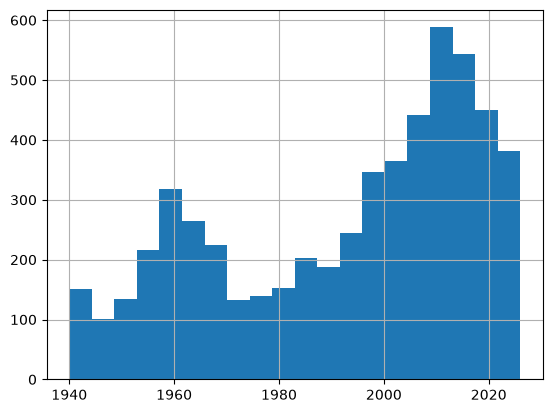

In [5]:
#QUESTION 2
#PART 3

# Range of Values
year_min, year_max = df["Year"].min(), df["Year"].max()
print(f'The values in the Year column range from Year {int(year_min)} to {int(year_max)}.')

# Check for missing values
print("Number of Null Entries in Year Column: " + str(df["Year"].isnull().sum())) #Orginal output was 2

# Determine null indices, inspect them with df.loc
null_indices = df[df["Year"].isnull()].index.tolist()
df.loc[null_indices] # Year is included in Date

# Replace null Year values for each index based on Date (null indices retained in null_indices)
df.loc[970, "Year"] = 2017
df.loc[6885, "Year"] = 1836

# Filter rows so only attacks from 1940 onward are included; plot histogram to diagnose trend in shark attacks
df_1940 = df[df["Year"] >= 1940]
df_1940["Year"].hist(bins=20)

#Final cleaning step: Convert float values into integers
df["Year"] = df["Year"].astype(int)



The histogram shows that shark attacks have generally increased in frequency since 1940

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


<Axes: >

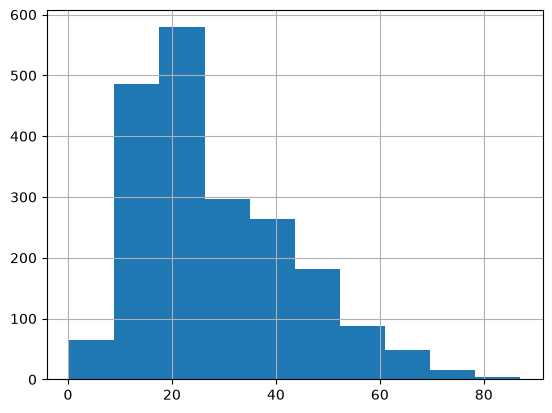

In [6]:
#QUESTION 2
#PART 4

# Detail Unique Values
print(df["Age"].unique()) # Reveals large number of non-numeric, null, or hybrid entries (ex: "18 months", "60+")

#Check for missing values
print("Number of Null Entries in Age Column: " + str(df["Age"].isnull().sum()))

df["Age"] = df["Age"].str.lower().str.strip()

#Set blank entries and junk answers to np.nan
df["Age"] = df["Age"].replace({
    '': np.nan,
    ' ': np.nan,
    "?": np.nan,
    "x": np.nan,
    "f": np.nan,
    "m": np.nan,
    "a.m.": np.nan,
    "make line green": np.nan
})

#Any values with exclamation points (!!, !2) will be treated as typos: Replace exclamations with 1
#Entries with plus signs, question marks, and greater than signs will have their respective punctuation removed
df["Age"] = df["Age"].replace({
    "!2": 12,
    "!!": 11,
    "!6": 16,
    "30+": 30,
    "40+": 40,
    "50+": 50, 
    "60+": 60,
    "20?": 20,
    "40?": 40,
    ">50": 50
})

#Entries that represent decades of age (50s, 40s, etc.) will be replaced with the midpoint of that decade
df["Age"] = df["Age"].replace({
    "30s": 35,
    "40s": 45,
    "50s": 55,
    "50's": 55,
    "60s": 60,
    "60's": 60,
    "mid-20s": 25,
    "mid-30s": 35,
    "20s": 25,
    "20's": 25,
    "20/30": 25
})

#All string descriptors of age will be replaced with ballpark estimates of the ages they're describing
df["Age"] = df["Age"].replace({
    "middle age": 40,
    "teen": 16,
    "a minor": 12,
    "teens": 16,
    "elderly": 65,
    "adult": 35,
    "(adult)": 35,
    '"middle-age"': 40,
    "young": 18,
    '"young"': 18
})

#Entries that list two or more ages will be replaced with the first available age in the entry
df["Age"] = df["Age"].replace({
   "45 and 15": 45,
   "9 & 60": 9,
   "28 & 22": 28,
   "22, 57, 31": 21,
   "28 & 26": 28,
   "18 or 20": 18,
   "12 or 13": 13,
   "46 & 34": 46,
   "28, 23 & 30": 28,
   "36 & 26": 36,
   "8 or 10": 8,
   "30 or 36": 30,
   "21 & ?": 21,
   "33 or 37": 33,
   "23 & 20": 23,
   '7      &    31': 7,
   "32 & 30": 32,
   "16 to 18": 16,
   "ca. 33": 33,
   "21 or 26": 21,
   "18 to 22": 18,
   "9 & 12": 9,
   "? & 19": 19,
   "25 to 35": 25,
   "23 & 26": 23,
   "33 & 37": 33,
   "25 or 28": 25,
   "37, 67, 35, 27,  ? & 27": 37,
   "21, 34,24 & 35": 21,
   "30 & 32": 30,
   "50 & 30": 50,
   "17 & 35": 17,
   "13 or 18": 13,
   "34 & 19": 34,
   "33 & 26": 33,
   "7 or 8": 7,
   "17 & 16": 17,
   "both 11": 11,
   "9 or 10": 9,
   "36 & 23": 36,
   "?    &   14": 14,
   "10 or 12": 10,
   "31 or 33": 31,
   "13 or 14": 13
})

#Any fractional or month values will be comverted into years
df["Age"] = df["Age"].replace({
   "18 months": 1.5,
   "6½": 6.5,
   "9 months": 0.75,
   "2 to 3 months": 0.25,
   "2½": 2.5
})

#Lastly, convert all string numbers to numeric values
df["Age"] = pd.to_numeric(df["Age"])

# Display Histogram
df["Age"].hist()

In [7]:
#QUESTION 2
#PART 5

# Detail all unique values in the Sex Column
print(df["Sex"].unique()) # Various entries that indicate men in column, like "M", " M", "M ", "M F", "M x 2", and "m"

# Clean select male indicators (" M", "M ", "m")
df_clean = df["Sex"].str.strip().str.upper()

# Filter out all non-male entries in the Sex column
num_male = df_clean.isin(["M", "M F", "M X 2"]).sum()
num_entries = df.shape[0]

print(f"Out of all shark attack victims, approximately {(num_male/num_entries)*100:.2f}% were men")

<StringArray>
['F', 'M', 'M ', 'M F', '?', 'F ', nan, ' M', 'm', 'lli', 'M x 2', 'N', '.']
Length: 13, dtype: str
Out of all shark attack victims, approximately 80.30% were men


In [8]:
#QUESTION 2
#PART 6

# Detail unique values in Type
print(df["Type"].unique()) # Reveals multiple entries that aren't Unprovoked, Provoked, and Unknown

# Replace all irregular entries with the intended labels in stages, putting the rest into Unknown
df["Type"] = df["Type"].replace({
    " Provoked": "Provoked",
    "UNprovoked": "Unprovoked",
    "unprovoked": "Unprovoked",
    "Sea Disaster": "Unknown",
    "Unconfirmed": "Unknown",
    "Under Investigation": "Unknown",
    np.nan: "Unknown",
    "Unverified": "Unknown",
    "Boat": "Unknown",
    "Questionable": "Unknown",
    "Watercraft": "Unknown",
    "?": "Unknown",
    "Invalid": "Unknown",
    "Under investigation": "Unknown"
})

# Find the proporation of attacks that are provoked
num_entries = df["Type"].shape[0]
num_provoked = df["Type"][df["Type"] == "Provoked"].count()

print(f"Out of all shark attacks, approximately {(num_provoked/num_entries)*100:.2f}% were provoked")

<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'UNprovoked',          'unprovoked',           ' Provoked',
          'Watercraft',        'Sea Disaster',                   nan,
                   '?',         'Unconfirmed',          'Unverified',
             'Invalid', 'Under investigation',                'Boat']
Length: 15, dtype: str
Out of all shark attacks, approximately 9.12% were provoked


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** Claude

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [9]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]